In [1]:
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import numpy as np
import h5py
#from common import smooth
from matplotlib.ticker import FormatStrFormatter

plt.rc('font', family='Times New Roman', size=14)
plt.rcParams['mathtext.fontset'] = 'custom'

plt.rcParams['mathtext.it'] = 'STIXGeneral:italic'
plt.rcParams['mathtext.rm'] = 'STIXGeneral:bold'
plt.rcParams['mathtext.tt'] = 'STIXGeneral'
plt.rcParams['mathtext.bf'] = 'STIXGeneral:bold:italic'
plt.rcParams['mathtext.cal'] = 'STIXGeneral'
plt.rcParams['mathtext.sf'] = 'STIXGeneral'

plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['axes.linewidth'] = 1.5

itr = r'$R$'
ite = r'$E$'

color_dict = {'HF':'tab:gray',
              'CASSCF':'tab:gray',
              'GW':'tab:red',
              'FCI':'black'}

color_dict = {'HF':'C1',
              'CASSCF':'C0',
              'GW0':'tab:green',
              'GW1':'tab:purple',
              'GW2':'tab:orange',
              'FCI':'black'}

In [2]:
from pyscf.data.nist import HARTREE2EV as au2ev
import numpy as np

theta = np.array( range(90,150,4) )

e0_ccsd = np.array([-224.4879461087393, -224.5164324855662, -224.537982082383, -224.5539098617323, -224.5652276441176, -224.5727170367964, -224.5769861995745, -224.5785130252447, -224.5776778981207, -224.5747886419877, -224.5700999676527, -224.5638292998908, -224.5561707040865, -224.5473073315798, -224.5374259193803])#, -224.526732074296])
e0_ccsdt = e0_ccsd + np.array([-0.0285033569524188, -0.0278415230219931, -0.0273803232073081, -0.0270590616729853, -0.0268369561333065, -0.026685379678959, -0.0265831894866606, -0.0265136793593173, -0.0264625246373813, -0.0264164908188358, -0.0263625507489167, -0.026287334877353, -0.0261768520007297, -0.0260161740169881, -0.0257902570973015])#, -0.0254844808666056])

ip_ccsd_a1 = np.array([0.5046528901, 0.4970658709, 0.4896490610, 0.4824107202, 0.4753199422, 0.4683351779, 0.4614151232, 0.4545203594, 0.4476145681, 0.4406627587, 0.4336323129, 0.4264946233, 0.4192288213, 0.4118303715, 0.4043052455])#, 0.3966966740])
ip_ccsd_a2 = np.array([0.4704686428, 0.4755646986, 0.4798470229, 0.4834008919, 0.4863116773, 0.4886554088, 0.4905035289, 0.4919250053, 0.4929774723, 0.4937113883, 0.4941687067, 0.4943831464, 0.4943820550, 0.4941886511, 0.4938220244])#, 0.4933034214])
ip_ccsd_b2 = np.array([0.3980095824, 0.4138063272, 0.4269449598, 0.4378699199, 0.4469451441, 0.4544688067, 0.4606863340, 0.4658004916, 0.4699791220, 0.4733608492, 0.4760598257, 0.4781702093, 0.4797708235, 0.4809300057, 0.4817104638])#, 0.4821747217])

ip_mrgw64_a1 = np.array([14.0000000000, 13.8000000000, 13.6000000000, 13.3900000000, 13.1900000000, 12.9900000000, 12.8000000000, 12.5900000000, 12.3800000000, 12.1800000000, 11.9700000000, 11.7600000000, 11.5400000000, 11.3300000000, 11.1000000000])/au2ev#, 10.8900000000])/au2ev
ip_mrgw64_b2 = np.array([11.4600000000, 11.8300000000, 12.1400000000, 12.3800000000, 12.5800000000, 12.7400000000, 12.8600000000, 12.9600000000, 13.0300000000, 13.0800000000, 13.1000000000, 13.1100000000, 13.0900000000, 13.0700000000, 13.0200000000])/au2ev#, 12.9600000000])
ip_mrgw64_a2 = np.array([14.1100000000, 14.2300000000, 14.3200000000, 14.4000000000, 14.4600000000, 14.5100000000, 14.5400000000, 14.5600000000, 14.5800000000, 14.5800000000, 14.5700000000, 14.5500000000, 14.5200000000, 14.4900000000, 14.4400000000])/au2ev

ip_mrgw85_a1 = np.array([12.3100000000, 12.3100000000, 12.2500000000, 12.1500000000, 12.0200000000, 11.8600000000, 11.7100000000, 11.5300000000, 11.3400000000, 11.1400000000, 10.9300000000, 10.7100000000, 10.4800000000, 10.2400000000, 10.0000000000])/au2ev
ip_mrgw85_b2 = np.array([10.7000000000, 11.0700000000, 11.3700000000, 11.6000000000, 11.7900000000, 11.9300000000, 12.0400000000, 12.1100000000, 12.1500000000, 12.1700000000, 12.1600000000, 12.1300000000, 12.0800000000, 12.0100000000, 11.9200000000])/au2ev
ip_mrgw85_a2 = np.array([12.4600000000, 12.5900000000, 12.7000000000, 12.7800000000, 12.8500000000, 12.8900000000, 12.9200000000, 12.9400000000, 12.9500000000, 12.9400000000, 12.9300000000, 12.9100000000, 12.8800000000, 12.8400000000, 12.7900000000])/au2ev

ip_cas86_a1 = np.array([14.1602554911, 14.2422659961, 14.2420464195, 14.1899368857, 14.1044178564, 13.9963629323, 13.8719980833, 13.7347447348, 13.5863270560, 13.4274443698, 13.2582008376, 13.0784074482, 12.8878247010, 12.6863868963, 12.4744848057])/au2ev#, 12.2532610891])/au2ev
ip_cas86_b2 = np.array([12.7142975700, 13.0626021145, 13.3461165000, 13.5768297315, 13.7639578349, 13.9145823621, 14.0340910173, 14.1264929393, 14.1946529710, 14.2404686482, 14.2650022282, 14.2685782257, 14.2508632619, 14.2109613391, 14.1475512749])/au2ev#, 14.0592304973])/au2ev
ip_cas86_a2 = np.array([12.8184518682, 12.9296505155, 13.0236807972, 13.1020694681, 13.1664066723, 13.2182347055, 13.2589556487, 13.2897688480, 13.3116374694, 13.3252766899, 13.3311536980, 13.3294906158, 13.3202642378, 13.3032003591, 13.2777624399])/au2ev#, 13.2431593542])/au2ev

#ip_mrgw86_a1 = np.array([13.3400000000, 12.5700000000, 12.5100000000, 12.4200000000, 12.3000000000, 12.1600000000, 12.0300000000, 11.8800000000, 11.7200000000, 11.5400000000, 11.3600000000, 11.1700000000, 10.9700000000, 10.7500000000, 10.5200000000])/au2ev
ip_mrgw86_a1 = np.array([12.5700000000, 12.5700000000, 12.5100000000, 12.4200000000, 12.3000000000, 12.1600000000, 12.0300000000, 11.8800000000, 11.7200000000, 11.5400000000, 11.3600000000, 11.1700000000, 10.9700000000, 10.7500000000, 10.5200000000])/au2ev
ip_mrgw86_b2 = np.array([10.8100000000, 11.1800000000, 11.4800000000, 11.7400000000, 11.9400000000, 12.1300000000, 12.2500000000, 12.3600000000, 12.4400000000, 12.5000000000, 12.5400000000, 12.5600000000, 12.5500000000, 12.5300000000, 12.4700000000])/au2ev
ip_mrgw86_a2 = np.array([12.5700000000, 12.7000000000, 12.8100000000, 12.9000000000, 12.9700000000, 13.0200000000, 13.0600000000, 13.0900000000, 13.1100000000, 13.1200000000, 13.1200000000, 13.1200000000, 13.1000000000, 13.0700000000, 13.0400000000])/au2ev

ip_srgw_a1 = np.array([14.7247308088, 14.4660878974, 14.2262778382, 14.0013285770, 13.7876749032, 13.5822957021, 13.3826891498, 13.1867818648, 12.9928307950, 12.7993555786, 12.6051224250, 12.4091874555, 12.2109975055, 12.0105364191, 11.8085771253])/au2ev#, 11.6068979106])/au2ev
ip_srgw_b2 = np.array([11.6377181178, 12.0848920819, 12.4582911861, 12.7707907389, 13.0328472092, 13.2529754768, 13.4381451197, 13.5940926231, 13.7255576380, 13.8364591050, 13.9300314161, 14.0089377238, 14.0753710812, 14.1311659367, 14.1777496165])/au2ev#, 14.2162798896])/au2ev
ip_srgw_a2 = np.array([12.5528936640, 12.6989750573, 12.8241969147, 12.9308595830, 13.0211759923, 13.0972305871, 13.1609486085, 13.2140653157, 13.2580954857, 13.2943112383, 13.3237372911, 13.3471678963, 13.3652016428, 13.3782743794, 13.3867709628])/au2ev#, 13.3910407303])/au2ev

ip_kt_a1 = -np.array([-0.619761449271716, -0.608653701342267, -0.598772922210894, -0.589848378830699, -0.581658380969988, -0.574022995006905, -0.56679720249488, -0.559864595095496, -0.553132097153839, -0.546526274956551, -0.539991584203316, -0.53349061858814, -0.527006110946976, -0.520544073876354, -0.514139954679231])#, -0.507861436470858])
ip_kt_b2 = -np.array([-0.510947259214513, -0.52697109684053, -0.540282801386546, -0.551378927501827, -0.560660080152632, -0.568452840251447, -0.57502702232806, -0.580608975009564, -0.585391526837289, -0.589541279297201, -0.59320408150514, -0.596509346484591, -0.599573537071805, -0.602503933830421, -0.605390802159481])#, -0.60830922850632])
ip_kt_a2 = -np.array([-0.476197282130788, -0.480187908513577, -0.483719760396288, -0.486836227493206, -0.489586256404906, -0.492020933687446, -0.494190991469713, -0.496144520364297, -0.497924751568545, -0.499568171845313, -0.501103299745178, -0.502550238068245, -0.503920684846578, -0.505216634413436, -0.506436109604324])#, -0.507567756416211])

ip_adc2_a1 = np.array([0.4340346793, 0.4278852911, 0.4217161693, 0.4155602364, 0.4094212676, 0.4032903899, 0.3971540434, 0.3909970963, 0.3848037578, 0.3785580897, 0.3722453701, 0.3658548813, 0.3593842423, 0.3528443944, 0.3462701794])#, 0.3397254758])
ip_adc2_b2 = np.array([0.3405797411, 0.3544799657, 0.3658261601, 0.3750858769, 0.3826323406, 0.3887647985, 0.3937254371, 0.3977125245, 0.4008902196, 0.4033959037, 0.4053460236, 0.4068412218, 0.4079710487, 0.4088177552, 0.4094594972])#, 0.4099700192])
ip_adc2_a2 = np.array([0.4542091023, 0.4605205384, 0.4657525279, 0.4700345278, 0.4734850411, 0.4762110197, 0.4783076287, 0.4798581747, 0.4809342510, 0.4815963243, 0.4818950069, 0.4818731205, 0.4815684903, 0.4810175859, 0.4802579024])#, 0.4793332080])



In [9]:
e0_dmrg_a1 = np.array([-224.523581535518275, -224.550899800306496, -224.571623630287633, -224.586963003538983, -224.597847781650074, -224.605014215404481, -224.609045801391915, -224.610384048080988, -224.609275082263480, -224.606395952446121, -224.601649421663211, -224.595308155747944, -224.587603614939837, -224.578575454761790, -224.568471458811757])#, -224.557538218631464])
e0_dmrg_a1_3000 = np.array([-224.523408360818820, -224.550725822486328, -224.571451865745274, -224.586795902368635, -224.597672330158701, -224.604815735797217, -224.608825808676727, -224.610125293424716, -224.608819230503741, -224.606042268917349, -224.601308403860656, -224.594970077987853, -224.587337901275191, -224.578269877637638, -224.568098421156492])#, -224.557184510316119])

ei_dmrg_a1 = np.array([-224.052337691318229, -224.073443510265434, -224.094724541037834, -224.113390699637591, -224.128943942744314, -224.141514444615609, -224.151410459426074, -224.158910191926367, -224.164186413272887, -224.167986523881211, -224.170074307355293, -224.170774354331797, -224.170335174578838, -224.168707129879976, -224.166170400418480])
ei_dmrg_a1_3000 = np.array([-224.051807390432799, -224.072896702177530, -224.094209732901135, -224.112918507925997, -224.128485864099190, -224.141032552013428, -224.150907297086405, -224.158354666049348, -224.163392816118517, -224.167341127325415, -224.169436945127899, -224.170144891537404, -224.169824345568202, -224.168140873395828, -224.165517765968843])


ei_dmrg_b2_3000 = np.array([-224.119602499269121, -224.132511599458979, -224.141300690009729, -224.146822213417408, -224.149625342560768, -224.150178126491880, -224.148895026282560, -224.145966408821579, -224.141328893974844, -224.136384474758529, -224.130119880201988, -224.122927720317193, -224.115208585471805, -224.106551035639768, -224.097586548201718])#, -224.088696224929265])
ei_dmrg_b2 = np.array([-224.119960113031055, -224.132879833362296, -224.141678339373840, -224.147194308291716, -224.150022304084615, -224.150631847976797, -224.149404679775159, -224.146576677360343, -224.142233699916630, -224.137136295200378, -224.130877485759896, -224.123726575075523, -224.115928931604856, -224.107408068744519, -224.098547578623482])#, -224.089624945899175])

ei_dmrg_a2_3000 = np.array([-224.050121507268699, -224.073489781729592, -224.090817398260214, -224.103282919576714, -224.111770097678090, -224.117203470271818, -224.119440108525168, -224.119558751460914, -224.117429302433891, -224.114086114038571, -224.109036149588604, -224.102601894974384, -224.095130320988119, -224.086421707853560, -224.076940797329428])#, -224.067464141713231])                                                                                                                                # -224.075834350816251
ei_dmrg_a2 = np.array([-224.050359577245132, -224.073706298703456, -224.091026015893959, -224.103484518075163, -224.111978261561859, -224.117157640389223, -224.119702092911098, -224.119866963391331, -224.117922252635083, -224.114482658252996, -224.109430773170089, -224.103021472607793, -224.095494342377549, -224.086881779068733, -224.077549791719434])#, -224.068310305251032])


In [10]:
x = ei_dmrg_a1 - e0_dmrg_a1
y = ei_dmrg_a1_3000 - e0_dmrg_a1_3000

print(np.abs(x-y).max())

0.0003728302677359352


In [43]:
casci129 = np.array([0.875788783086, 0.882189526650, 0.886916752885, 0.890440513401, 0.893032659220, 0.894882903290, 0.896112262888, 0.896799982303, 0.896998869804, 0.896745702149, 0.896069394234, 0.895001353385, 0.893581705606, 0.891882969824, 0.890046027975, 0.888318528290])
casci86 = np.array([0.905323907723, 0.908980291606, 0.912048766406, 0.914648710492, 0.916866351826, 0.918760675135, 0.920370204241, 0.921719148100, 0.922822539783, 0.923690408634, 0.924331373049, 0.924756482800, 0.924984531968, 0.925049798460, 0.925018248836, 0.925006197864])
casci64 = np.array([0.920210539246, 0.923420949972, 0.926226344659, 0.928727219217, 0.931001301179, 0.933108486747, 0.935094506038, 0.936993418914, 0.938828989956, 0.940615019513, 0.942354571228, 0.944037772256, 0.945637381940, 0.947099704391, 0.948334771271, 0.949187428008])

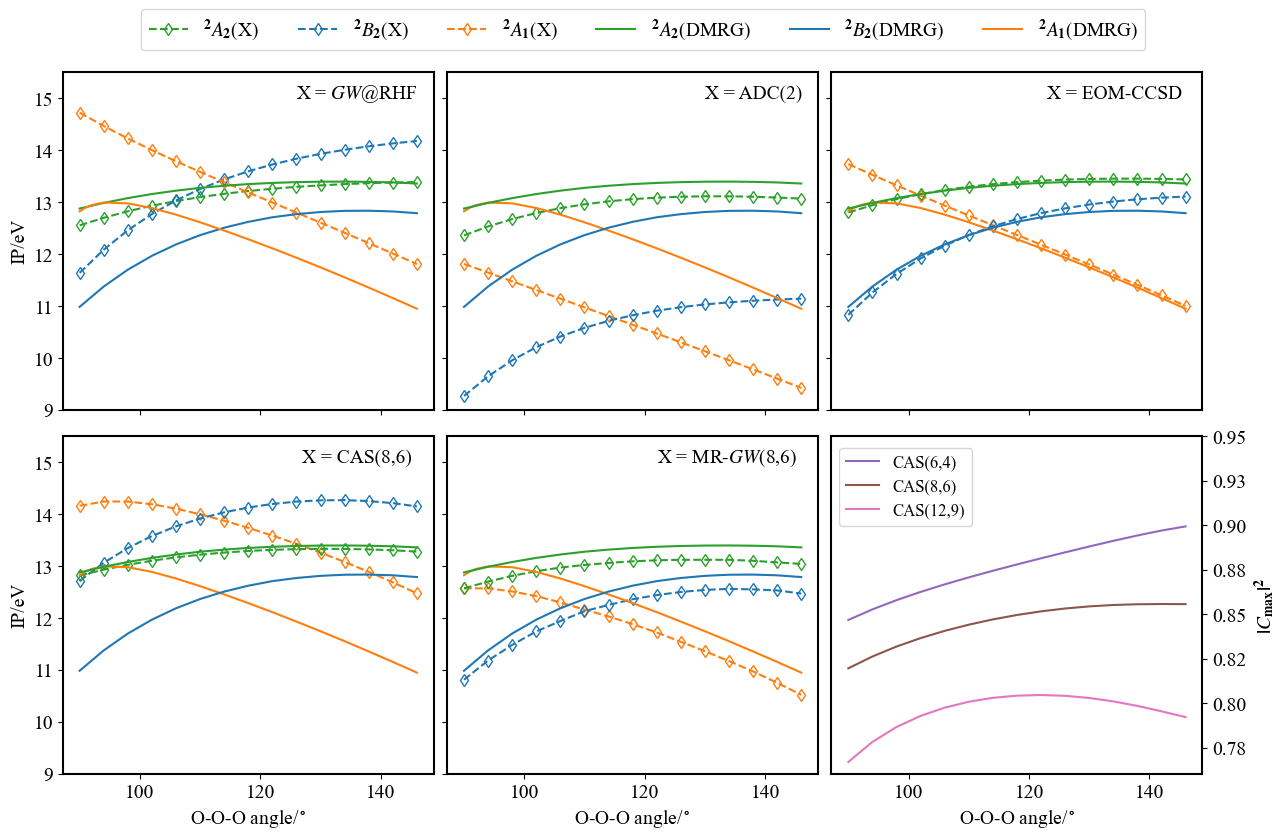

In [66]:
fig,[(ax1,ax2,ax3),(ax4,ax5,ax6)] = plt.subplots(nrows=2, ncols=3, figsize=(15*.85,9*.85), constrained_layout=True)

y0 = 9; y1 = 15.5

#plt.tight_layout()

ax = ax6

ax.plot(theta, casci64[:-1]**2, label='CAS(6,4)', color='C4')
ax.plot(theta, casci86[:-1]**2, label='CAS(8,6)', color='C5')
ax.plot(theta, casci129[:-1]**2, label='CAS(12,9)', color='C6')
ax.set_ylabel(r'$|C_\text{max}|^2$')
ax.legend(fontsize=12, loc='center', bbox_to_anchor=(.2,.85))
ax.set_ylim(top=.95)
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
#ax.spines['left'].set_visible(False)
#ax.spines['right'].set_visible(True)  


# ---- GW@RHF ----

ax = ax1

x = theta; y = ip_srgw_a2*au2ev
ax.plot(x, y, label=r'$^2A_2$(X)', color='C2', ls='--', marker='d', mfc='none')
x = theta; y = ip_srgw_b2*au2ev
ax.plot(x, y, label=r'$^2B_2$(X)', color='C0', ls='--', marker='d', mfc='none')
x = theta; y = ip_srgw_a1*au2ev
ax.plot(x, y, label=r'$^2A_1$(X)', color='C1', ls='--', marker='d', mfc='none')

x = theta; y = (ei_dmrg_a2 - e0_dmrg_a1)*au2ev
ax.plot(x, y, label=r'$^2A_2$(DMRG)', color='C2', ls='-')
x = theta; y = (ei_dmrg_b2 - e0_dmrg_a1)*au2ev
ax.plot(x, y, label=r'$^2B_2$(DMRG)', color='C0', ls='-')
x = theta; y = (ei_dmrg_a1 - e0_dmrg_a1)*au2ev
x = [theta[0]] + [91,92] + list(theta[1:])
y = [y[0]] + [(-224.057248563068043+224.531107003756432)*au2ev, (-224.062493757974352+224.538152469312735)*au2ev] + list(y[1:])
x = np.asarray(x); y = np.asarray(y)
ax.plot(x, y, label=r'$^2A_1$(DMRG)', color='C1', ls='-')



# ---- ADC ----

ax = ax2

x = theta; y = ip_adc2_a1*au2ev
ax.plot(x, y, label=r'$^2A_2$/$GW$@RHF', color='C1', ls='--', marker='d', mfc='none')
x = theta; y = ip_adc2_b2*au2ev
ax.plot(x, y, label=r'$^2A_2$/$GW$@RHF', color='C0', ls='--', marker='d', mfc='none')
x = theta; y = ip_adc2_a2*au2ev
ax.plot(x, y, label=r'$^2A_2$/$GW$@RHF', color='C2', ls='--', marker='d', mfc='none')

x = theta; y = (ei_dmrg_a1 - e0_dmrg_a1)*au2ev
x = [theta[0]] + [91,92] + list(theta[1:])
y = [y[0]] + [(-224.057248563068043+224.531107003756432)*au2ev, (-224.062493757974352+224.538152469312735)*au2ev] + list(y[1:])
x = np.asarray(x); y = np.asarray(y)
ax.plot(x, y, label=r'$^2A_2$/DMRG', color='C1', ls='-')
x = theta; y = (ei_dmrg_b2 - e0_dmrg_a1)*au2ev
ax.plot(x, y, label=r'$^2A_2$/DMRG', color='C0', ls='-')
x = theta; y = (ei_dmrg_a2 - e0_dmrg_a1)*au2ev
ax.plot(x, y, label=r'$^2A_2$/DMRG', color='C2', ls='-')

# ==== CAS ====

ax = ax4

x = theta; y = ip_cas86_a1*au2ev
ax.plot(x, y, label=r'$^2A_2$/$GW$@RHF', color='C1', ls='--', marker='d', mfc='none')
x = theta; y = ip_cas86_b2*au2ev
ax.plot(x, y, label=r'$^2A_2$/$GW$@RHF', color='C0', ls='--', marker='d', mfc='none')
x = theta; y = ip_cas86_a2*au2ev
ax.plot(x, y, label=r'$^2A_2$/$GW$@RHF', color='C2', ls='--', marker='d', mfc='none')

x = theta; y = (ei_dmrg_a1 - e0_dmrg_a1)*au2ev
x = [theta[0]] + [91,92] + list(theta[1:])
y = [y[0]] + [(-224.057248563068043+224.531107003756432)*au2ev, (-224.062493757974352+224.538152469312735)*au2ev] + list(y[1:])
x = np.asarray(x); y = np.asarray(y)
ax.plot(x, y, label=r'$^2A_2$/DMRG', color='C1', ls='-')
x = theta; y = (ei_dmrg_b2 - e0_dmrg_a1)*au2ev
ax.plot(x, y, label=r'$^2A_2$/DMRG', color='C0', ls='-')
x = theta; y = (ei_dmrg_a2 - e0_dmrg_a1)*au2ev
ax.plot(x, y, label=r'$^2A_2$/DMRG', color='C2', ls='-')

# ==== MRGW ====

ax = ax5

x = theta; y = ip_mrgw86_a1*au2ev
ax.plot(x, y, label=r'$^2A_2$/$GW$@RHF', color='C1', ls='--', marker='d', mfc='none')
x = theta; y = ip_mrgw86_b2*au2ev
ax.plot(x, y, label=r'$^2A_2$/$GW$@RHF', color='C0', ls='--', marker='d', mfc='none')
x = theta; y = ip_mrgw86_a2*au2ev
ax.plot(x, y, label=r'$^2A_2$/$GW$@RHF', color='C2', ls='--', marker='d', mfc='none')

x = theta; y = (ei_dmrg_a1 - e0_dmrg_a1)*au2ev
x = [theta[0]] + [91,92] + list(theta[1:])
y = [y[0]] + [(-224.057248563068043+224.531107003756432)*au2ev, (-224.062493757974352+224.538152469312735)*au2ev] + list(y[1:])
x = np.asarray(x); y = np.asarray(y)
ax.plot(x, y, label=r'$^2A_2$/DMRG', color='C1', ls='-')
x = theta; y = (ei_dmrg_b2 - e0_dmrg_a1)*au2ev
ax.plot(x, y, label=r'$^2A_2$/DMRG', color='C0', ls='-')
x = theta; y = (ei_dmrg_a2 - e0_dmrg_a1)*au2ev
ax.plot(x, y, label=r'$^2A_2$/DMRG', color='C2', ls='-')


# ==== EOM-CCSD ====
ax = ax3

x = theta; y = ip_ccsd_a1*au2ev
ax.plot(x, y, label=r'$^2A_2$/$GW$@RHF', color='C1', ls='--', marker='d', mfc='none')
x = theta; y = ip_ccsd_b2*au2ev
ax.plot(x, y, label=r'$^2A_2$/$GW$@RHF', color='C0', ls='--', marker='d', mfc='none')
x = theta; y = ip_ccsd_a2*au2ev
ax.plot(x, y, label=r'$^2A_2$/$GW$@RHF', color='C2', ls='--', marker='d', mfc='none')

x = theta; y = (ei_dmrg_a1 - e0_dmrg_a1)*au2ev
x = [theta[0]] + [91,92] + list(theta[1:])
y = [y[0]] + [(-224.057248563068043+224.531107003756432)*au2ev, (-224.062493757974352+224.538152469312735)*au2ev] + list(y[1:])
x = np.asarray(x); y = np.asarray(y)
ax.plot(x, y, label=r'$^2A_2$/DMRG', color='C1', ls='-')
x = theta; y = (ei_dmrg_b2 - e0_dmrg_a1)*au2ev
ax.plot(x, y, label=r'$^2A_2$/DMRG', color='C0', ls='-')
x = theta; y = (ei_dmrg_a2 - e0_dmrg_a1)*au2ev
ax.plot(x, y, label=r'$^2A_2$/DMRG', color='C2', ls='-')


# ====
ax6.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

ax4.set_xlabel(r'O-O-O angle/$^\circ$')
ax5.set_xlabel(r'O-O-O angle/$^\circ$')
ax6.set_xlabel(r'O-O-O angle/$^\circ$')

ax1.text(s=r'X = $GW$@RHF', x=126, y=15)
ax2.text(s='X = ADC(2)', x=130, y=15)
ax4.text(s='X = CAS(8,6)', x=127, y=15)
ax5.text(s=r'X = MR-$GW$(8,6)', x=122, y=15)
ax3.text(s='X = EOM-CCSD', x=123, y=15)

for ax in [ax1,ax2,ax3]:
    ax.set_xticks([100,120,140])
    ax.set_xticklabels([])

for ax in [ax1,ax2,ax3,ax4,ax5]:
    ax.set_ylim(y0,y1)
    ax.set_yticks(np.arange(y0,y1))

ax1.set_ylabel('IP/eV')
ax4.set_ylabel('IP/eV')

for ax in [ax2,ax3,ax5]:
    ax.set_yticklabels([])

lines, labels = fig.axes[0].get_legend_handles_labels()
ncol = 6
fig.legend(lines, labels, loc="center", bbox_to_anchor=(.5,1.05),ncol=ncol, labelspacing=.5)

plt.savefig('o3-bending-ip-and-cmax.pdf', format='pdf', bbox_inches='tight')
